# Unit 2 | NLP 03 — Classical Text Classification & Explainability

This notebook builds end-to-end text classification pipelines and interprets their decisions:

1. **sklearn Pipelines** — vectorize + classify in one step, no data leakage
2. **Three classifiers** — Multinomial Naive Bayes, Logistic Regression, Random Forest
3. **Evaluation** — classification report, confusion matrix
4. **RF Feature Importance** — which words matter most?
5. **SHAP** — per-prediction word-level attribution

**Dataset:** sklearn 20 Newsgroups

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import shap

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('dark_background')

In [2]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
CATEGORIES   = ['sci.space', 'comp.graphics', 'rec.sport.hockey', 'talk.religion.misc']
RANDOM_STATE = 42
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
train = fetch_20newsgroups(
    subset='train', categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'), random_state=RANDOM_STATE
)
test = fetch_20newsgroups(
    subset='test', categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'), random_state=RANDOM_STATE
)

print(f"Train: {len(train.data):,} docs   Test: {len(test.data):,} docs")
print(f"Classes: {train.target_names}")

Train: 2,154 docs   Test: 1,433 docs
Classes: ['comp.graphics', 'rec.sport.hockey', 'sci.space', 'talk.religion.misc']


## Section 1: Simple Classification Workflow

The canonical three-step pattern for text classification:

1. **Vectorize** — fit a `TfidfVectorizer` on *training data only*, then transform both splits
2. **Fit** — train a classifier on the training feature matrix
3. **Evaluate** — predict on the held-out test set and measure performance

The key rule: the vectorizer must be fit only on training data. Transforming test data with the same fitted vectorizer ensures no test-set vocabulary statistics leak into the features.

TF-IDF + Logistic Regression — Simple Workflow
                    precision    recall  f1-score   support

     comp.graphics       0.89      0.90      0.90       389
  rec.sport.hockey       0.97      0.92      0.94       399
         sci.space       0.79      0.91      0.85       394
talk.religion.misc       0.91      0.75      0.83       251

          accuracy                           0.88      1433
         macro avg       0.89      0.87      0.88      1433
      weighted avg       0.89      0.88      0.88      1433



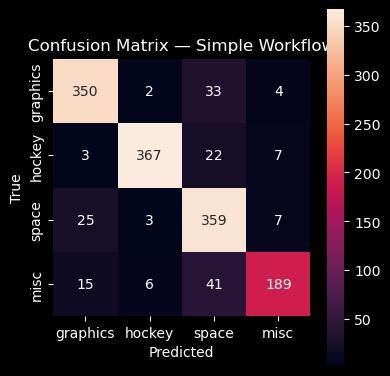

In [4]:
# 1. Vectorize — fit on train only, transform both splits
vec     = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vec.fit_transform(train.data)
X_test  = vec.transform(test.data)

# 2. Fit
clf = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
clf.fit(X_train, train.target)

# 3. Evaluate
y_pred_simple = clf.predict(X_test)

print('TF-IDF + Logistic Regression — Simple Workflow')
print('=' * 60)
print(classification_report(test.target, y_pred_simple, target_names=train.target_names))

cm = confusion_matrix(test.target, y_pred_simple)
short_names = [c.split('.')[-1] for c in train.target_names]
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(cm, annot=True, square=True, fmt='d',
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Simple Workflow')
plt.tight_layout()
plt.show()

## Section 2: Pipeline Collection — Systematic Comparison

Rather than hand-picking one configuration, we build and evaluate **207 pipelines** by combining 10 vectorizer configurations (CountVectorizer and TF-IDF with varied n-gram ranges, stop words, feature counts, and `min_df`) with 21 classifier configurations (Naive Bayes, Logistic Regression, LinearSVC, Random Forest, and SGD). All pipelines are fit on the training set and ranked by held-out macro F1, then we break down performance by each hyperparameter to see what actually moves the needle.

## 1. The sklearn Pipeline

A `Pipeline` chains steps so the same transformations applied to training data are automatically applied to test data. This **prevents data leakage** — the vectorizer never sees test documents during `fit`.

```python
Pipeline([
    ('vectorizer', TfidfVectorizer()),   # step 1: text → numbers
    ('classifier', LogisticRegression()) # step 2: numbers → predictions
])
```

Calling `pipeline.fit(X_train, y_train)` fits both steps in order.
Calling `pipeline.predict(X_test)` applies both transformations to test data.

In [5]:
from tqdm import tqdm
from sklearn.base import clone

# --- define vectorizers with explicit param dicts ---
vectorizer_configs = [
    dict(label='CountVec(1,1,sw,mindf1,feat1k)',    vec_type='CountVec', ngram='1,1', stop_words='english', sublinear=False, min_df=1,  max_feat=1000,  vec=CountVectorizer(max_features=1000,  stop_words='english', ngram_range=(1,1), min_df=1,  max_df=0.95)),
    dict(label='CountVec(1,1,nosw,mindf1,feat1k)',  vec_type='CountVec', ngram='1,1', stop_words=None,      sublinear=False, min_df=1,  max_feat=1000,  vec=CountVectorizer(max_features=1000,  stop_words=None,      ngram_range=(1,1), min_df=1,  max_df=0.95)),
    dict(label='CountVec(1,2,sw,mindf2,feat5k)',    vec_type='CountVec', ngram='1,2', stop_words='english', sublinear=False, min_df=2,  max_feat=5000,  vec=CountVectorizer(max_features=5000,  stop_words='english', ngram_range=(1,2), min_df=2,  max_df=0.95)),
    dict(label='CountVec(1,2,nosw,mindf5,feat10k)', vec_type='CountVec', ngram='1,2', stop_words=None,      sublinear=False, min_df=5,  max_feat=10000, vec=CountVectorizer(max_features=10000, stop_words=None,      ngram_range=(1,2), min_df=5,  max_df=0.95)),
    dict(label='CountVec(1,3,nosw,mindf1,feat500)', vec_type='CountVec', ngram='1,3', stop_words=None,      sublinear=False, min_df=1,  max_feat=500,   vec=CountVectorizer(max_features=500,   stop_words=None,      ngram_range=(1,3), min_df=1,  max_df=1.0)),   # bad

    dict(label='TFIDF(1,1,linear,sw,mindf2,feat5k)',    vec_type='TFIDF', ngram='1,1', stop_words='english', sublinear=False, min_df=2,  max_feat=5000,  vec=TfidfVectorizer(max_features=5000,  stop_words='english', ngram_range=(1,1), sublinear_tf=False, min_df=2,  max_df=0.95)),
    dict(label='TFIDF(1,1,sublin,sw,mindf2,feat5k)',    vec_type='TFIDF', ngram='1,1', stop_words='english', sublinear=True,  min_df=2,  max_feat=5000,  vec=TfidfVectorizer(max_features=5000,  stop_words='english', ngram_range=(1,1), sublinear_tf=True,  min_df=2,  max_df=0.95)),
    dict(label='TFIDF(1,2,sublin,sw,mindf5,feat10k)',   vec_type='TFIDF', ngram='1,2', stop_words='english', sublinear=True,  min_df=5,  max_feat=10000, vec=TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1,2), sublinear_tf=True,  min_df=5,  max_df=0.95)),
    dict(label='TFIDF(1,2,sublin,nosw,mindf2,feat20k)', vec_type='TFIDF', ngram='1,2', stop_words=None,      sublinear=True,  min_df=2,  max_feat=20000, vec=TfidfVectorizer(max_features=20000, stop_words=None,      ngram_range=(1,2), sublinear_tf=True,  min_df=2,  max_df=0.95)),
    dict(label='TFIDF(1,1,linear,nosw,mindf1,feat200)', vec_type='TFIDF', ngram='1,1', stop_words=None,      sublinear=False, min_df=1,  max_feat=200,   vec=TfidfVectorizer(max_features=200,   stop_words=None,      ngram_range=(1,1), sublinear_tf=False, min_df=1,  max_df=1.0)),   # bad
    dict(label='TFIDF(2,3,sublin,sw,mindf10,feat5k)',   vec_type='TFIDF', ngram='2,3', stop_words='english', sublinear=True,  min_df=10, max_feat=5000,  vec=TfidfVectorizer(max_features=5000,  stop_words='english', ngram_range=(2,3), sublinear_tf=True,  min_df=10, max_df=0.95)),  # bad
]

# --- define models with explicit param dicts ---
model_configs = [
    dict(label='NB(a=0.01)',           clf_type='NB',     nb_only=True,  C=None, alpha=0.01,  n_est=None, clf=MultinomialNB(alpha=0.01)),           # bad
    dict(label='NB(a=0.1)',            clf_type='NB',     nb_only=True,  C=None, alpha=0.1,   n_est=None, clf=MultinomialNB(alpha=0.1)),
    dict(label='NB(a=1.0)',            clf_type='NB',     nb_only=True,  C=None, alpha=1.0,   n_est=None, clf=MultinomialNB(alpha=1.0)),
    dict(label='NB(a=50.0)',           clf_type='NB',     nb_only=True,  C=None, alpha=50.0,  n_est=None, clf=MultinomialNB(alpha=50.0)),            # bad

    dict(label='LogReg(C=0.001)',      clf_type='LogReg', nb_only=False, C=0.001,   alpha=None, n_est=None, clf=LogisticRegression(C=0.001,    max_iter=1000, random_state=RANDOM_STATE)),  # bad
    dict(label='LogReg(C=0.1)',        clf_type='LogReg', nb_only=False, C=0.1,     alpha=None, n_est=None, clf=LogisticRegression(C=0.1,      max_iter=1000, random_state=RANDOM_STATE)),
    dict(label='LogReg(C=1.0)',        clf_type='LogReg', nb_only=False, C=1.0,     alpha=None, n_est=None, clf=LogisticRegression(C=1.0,      max_iter=1000, random_state=RANDOM_STATE)),
    dict(label='LogReg(C=10.0)',       clf_type='LogReg', nb_only=False, C=10.0,    alpha=None, n_est=None, clf=LogisticRegression(C=10.0,     max_iter=1000, random_state=RANDOM_STATE)),
    dict(label='LogReg(C=1000.0)',     clf_type='LogReg', nb_only=False, C=1000.0,  alpha=None, n_est=None, clf=LogisticRegression(C=1000.0,   max_iter=1000, random_state=RANDOM_STATE)),  # bad

    dict(label='SVC(C=0.001)',         clf_type='SVC',    nb_only=False, C=0.001,   alpha=None, n_est=None, clf=LinearSVC(C=0.001,  max_iter=2000, random_state=RANDOM_STATE)),  # bad
    dict(label='SVC(C=0.1)',           clf_type='SVC',    nb_only=False, C=0.1,     alpha=None, n_est=None, clf=LinearSVC(C=0.1,    max_iter=2000, random_state=RANDOM_STATE)),
    dict(label='SVC(C=1.0)',           clf_type='SVC',    nb_only=False, C=1.0,     alpha=None, n_est=None, clf=LinearSVC(C=1.0,    max_iter=2000, random_state=RANDOM_STATE)),
    dict(label='SVC(C=10.0)',          clf_type='SVC',    nb_only=False, C=10.0,    alpha=None, n_est=None, clf=LinearSVC(C=10.0,   max_iter=2000, random_state=RANDOM_STATE)),
    dict(label='SVC(C=1000.0)',        clf_type='SVC',    nb_only=False, C=1000.0,  alpha=None, n_est=None, clf=LinearSVC(C=1000.0, max_iter=2000, random_state=RANDOM_STATE)),  # bad

    dict(label='RF(n=5,depth=2)',      clf_type='RF',     nb_only=False, C=None, alpha=None, n_est=5,   clf=RandomForestClassifier(n_estimators=5,   max_depth=2,    random_state=RANDOM_STATE, n_jobs=-1)),  # bad
    dict(label='RF(n=100,depthNone)',  clf_type='RF',     nb_only=False, C=None, alpha=None, n_est=100, clf=RandomForestClassifier(n_estimators=100, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)),
    dict(label='RF(n=200,depthNone)',  clf_type='RF',     nb_only=False, C=None, alpha=None, n_est=200, clf=RandomForestClassifier(n_estimators=200, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)),

    dict(label='SGD(hinge,lr=0.0001)', clf_type='SGD',    nb_only=False, C=None, alpha=None, n_est=None, clf=SGDClassifier(loss='hinge',    learning_rate='constant', eta0=0.0001, max_iter=100, random_state=RANDOM_STATE, n_jobs=-1)),  # bad
    dict(label='SGD(hinge,optimal)',   clf_type='SGD',    nb_only=False, C=None, alpha=None, n_est=None, clf=SGDClassifier(loss='hinge',    learning_rate='optimal',               max_iter=100, random_state=RANDOM_STATE, n_jobs=-1)),
    dict(label='SGD(log_loss,optimal)',clf_type='SGD',    nb_only=False, C=None, alpha=None, n_est=None, clf=SGDClassifier(loss='log_loss', learning_rate='optimal',               max_iter=100, random_state=RANDOM_STATE, n_jobs=-1)),
    dict(label='SGD(hinge,lr=10.0)',   clf_type='SGD',    nb_only=False, C=None, alpha=None, n_est=None, clf=SGDClassifier(loss='hinge',    learning_rate='constant', eta0=10.0,   max_iter=100, random_state=RANDOM_STATE, n_jobs=-1)),  # bad
]

# --- build pipelines, recording all params up front ---
records = []
pipelines = {}

count_vec_labels = {vc['label'] for vc in vectorizer_configs if vc['vec_type'] == 'CountVec'}

for vc in vectorizer_configs:
    for mc in model_configs:
        if mc['nb_only'] and vc['vec_type'] != 'CountVec':
            continue
        label = f"{vc['label']} + {mc['label']}"
         pipelines[label] = Pipeline([('vec', clone(vc['vec'])), ('clf', clone(mc['clf']))])
        records.append({
            'label'      : label,
            'vec_type'   : vc['vec_type'],
            'ngram'      : vc['ngram'],
            'stop_words' : str(vc['stop_words']),
            'sublinear'  : vc['sublinear'],
            'min_df'     : vc['min_df'],
            'max_feat'   : vc['max_feat'],
            'clf_type'   : mc['clf_type'],
            'C'          : mc['C'],
            'alpha'      : mc['alpha'],
            'n_est'      : mc['n_est'],
        })

params_df = pd.DataFrame(records)
print(f"{len(pipelines)} pipelines total")

IndentationError: unexpected indent (889323260.py, line 60)

In [ ]:
# --- fit and evaluate ---
pd.set_option('display.max_colwidth', None)

n = len(pipelines)
f1_scores  = []
accuracies = []

with tqdm(pipelines.items(), total=n) as pbar:
    for i, (label, pipe) in enumerate(pbar):
        pipe.fit(train.data, train.target)
        y_pred = pipe.predict(test.data)
        acc    = accuracy_score(test.target, y_pred)
        f1     = f1_score(test.target, y_pred, average='macro')
        f1_scores.append(f1)
        accuracies.append(acc)
        #pbar.set_description(f"[{i+1}/{n}] {label}")
        #pbar.set_postfix(Acc=f"{acc:.4f}", MacroF1=f"{f1:.4f}")

params_df['Accuracy'] = accuracies
params_df['Macro F1'] = f1_scores
params_df = params_df.sort_values('Macro F1', ascending=False)

In [ ]:
# --- describe performance by each param ---
params = [
    'vec_type', 'ngram', 'stop_words', 'sublinear',
    'clf_type', 'min_df', 'max_feat', 'C', 'alpha', 'n_est'
]

for param in params:
    print(f"\n{'='*60}")
    print(f"Macro F1 by {param}")
    print('='*60)
    print(params_df.groupby(param)['Macro F1'].describe().round(4))

In [ ]:
best_label = params_df.iloc[0]['label']
best_preds = pipelines[best_label].predict(test.data)

print(f'Classification Report — {best_label}')
print('='*60)
print(classification_report(test.target, best_preds, target_names=train.target_names))

cm = confusion_matrix(test.target, best_preds)
short_names = [c.split('.')[-1] for c in train.target_names]

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(cm, annot=True, square=True, fmt='d',
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_label}')
plt.tight_layout()
plt.show()

## Section 3: Grid Search — TF-IDF + Logistic Regression

`GridSearchCV` automates hyperparameter search by exhaustively evaluating every combination in a parameter grid using **k-fold cross-validation**. The key difference from the pipeline collection above:

| | Pipeline Collection | Grid Search |
|---|---|---|
| Evaluation | Single train/test split | k-fold CV on training set |
| Parameter space | Hand-crafted combinations | Cartesian product of grid |
| Overfitting risk | Higher (one test set) | Lower (averaged over k folds) |

Below we search over TF-IDF and Logistic Regression hyperparameters simultaneously with 5-fold CV scored by macro F1.

In [ ]:
from sklearn.model_selection import GridSearchCV

gs_pipe = Pipeline([
    ('vec', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

param_grid = {
    'vec__ngram_range': [(1, 1), (1, 2)],
    'vec__max_features': [5000, 10000],
    'vec__sublinear_tf': [True, False],
    'clf__C': [0.1, 1.0, 10.0],
}

gs = GridSearchCV(gs_pipe, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
gs.fit(train.data, train.target)

print(f'Best params:        {gs.best_params_}')
print(f'Best CV F1 (macro): {gs.best_score_:.4f}')
print()

gs_results = pd.DataFrame(gs.cv_results_)
cols = [
    'param_vec__ngram_range', 'param_vec__max_features',
    'param_vec__sublinear_tf', 'param_clf__C',
    'mean_test_score', 'std_test_score', 'rank_test_score',
]
print(gs_results[cols].sort_values('rank_test_score').head(10).to_string(index=False))

y_pred_gs = gs.best_estimator_.predict(test.data)
print('\nTest-set performance (best grid search model):')
print('=' * 60)
print(classification_report(test.target, y_pred_gs, target_names=train.target_names))

## Section 4: Feature Importance

Three complementary ways to understand what the model has learned:

| Method | Scope | Direction | Model |
|---|---|---|---|
| RF Feature Importance | Global | Unsigned | Random Forest |
| LR Coefficients | Per-class | Signed | Logistic Regression |
| SHAP | Local (per-doc) | Signed | Any linear model |

In [ ]:
# Random Forest — global unsigned importance
rf_pipe = pipelines['TFIDF(1,1,sublin,sw,mindf2,feat5k) + RF(n=100,depthNone)']
rf_vec  = rf_pipe.named_steps['vec']
rf_clf  = rf_pipe.named_steps['clf']

feature_names = rf_vec.get_feature_names_out()
importances   = rf_clf.feature_importances_

top_n   = 20
top_idx = importances.argsort()[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(top_n), importances[top_idx], color='#5b8dd9')
ax.set_xticks(range(top_n))
ax.set_xticklabels(feature_names[top_idx], rotation=45, ha='right')
ax.set_ylabel('Feature Importance')
ax.set_title(f'Top {top_n} Words — Random Forest (Global, Unsigned)')
plt.tight_layout()
plt.show()

In [ ]:
# Logistic Regression — per-class signed coefficients
lr_pipe     = pipelines['TFIDF(1,1,sublin,sw,mindf2,feat5k) + LogReg(C=1.0)']
lr_vec      = lr_pipe.named_steps['vec']
lr_clf      = lr_pipe.named_steps['clf']
lr_features = lr_vec.get_feature_names_out()

n_cats    = len(train.target_names)
top_per   = 10
fig, axes = plt.subplots(1, n_cats, figsize=(5 * n_cats, 5))

for ax, class_idx, cat in zip(axes, range(n_cats), train.target_names):
    coefs   = lr_clf.coef_[class_idx]
    top_pos = coefs.argsort()[::-1][:top_per]
    words   = lr_features[top_pos]
    scores  = coefs[top_pos]
    ax.barh(list(words)[::-1], list(scores)[::-1], color='#5bd95b')
    ax.set_title(cat.split('.')[-1], fontsize=10)
    ax.set_xlabel('LR Coefficient')

plt.suptitle('Top Words per Class — LR Coefficients (Per-Class, Signed)', fontsize=13)
plt.tight_layout()
plt.show()

### SHAP — SHapley Additive exPlanations

SHAP assigns each word a credit score for a **specific prediction**: positive values push toward the predicted class, negative values push away. This is fundamentally different from the global/unsigned methods above.

We use `shap.LinearExplainer` with the TF-IDF + Logistic Regression pipeline. The explainer requires a dense background dataset (training data converted from sparse), then computes per-document attribution scores over the test set.

In [ ]:
# lr_pipe, lr_vec, lr_clf, lr_features defined in LR coefficients cell above
X_train_tfidf = lr_vec.transform(train.data)
X_test_tfidf  = lr_vec.transform(test.data)

# LinearExplainer requires dense arrays — convert from sparse
X_train_dense = X_train_tfidf.toarray()
X_test_dense  = X_test_tfidf[:200].toarray()

explainer   = shap.LinearExplainer(lr_clf, X_train_dense)
shap_values = explainer.shap_values(X_test_dense)
# For a 4-class model: list of 4 arrays, each shape (n_samples, n_features)

print(f'Classes:              {len(shap_values)}')
print(f'SHAP shape per class: {shap_values[0].shape}')
print('One array per class; rows = documents, columns = vocabulary features.')

In [ ]:
# Global SHAP bar chart — one panel per class, top 10 words by mean |SHAP|
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, cat in enumerate(train.target_names):
    plt.sca(axes[i])
    shap.summary_plot(
        shap_values[i],
        X_test_dense,
        feature_names=lr_features,
        plot_type='bar',
        max_display=10,
        show=False,
    )
    axes[i].set_title(cat.split('.')[-1], fontsize=11)

plt.suptitle('SHAP Feature Importance per Class (Top 10 by Mean |SHAP|)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Local explanation — why did the model predict what it did for one document?
doc_i    = 5
doc_text = test.data[doc_i]
true_cat = train.target_names[test.target[doc_i]]
pred_cat = train.target_names[lr_pipe.predict([doc_text])[0]]

print(f'True:      {true_cat}')
print(f'Predicted: {pred_cat}')
print()
print('Document excerpt:')
print(doc_text[:400])
print()

pred_class_idx  = lr_pipe.predict([doc_text])[0]
sv              = shap_values[pred_class_idx][doc_i]

top_contrib_idx = np.abs(sv).argsort()[::-1][:15]
contrib_words   = lr_features[top_contrib_idx]
contrib_vals    = sv[top_contrib_idx]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#5bd95b' if v > 0 else '#d95b5b' for v in contrib_vals[::-1]]
ax.barh(list(contrib_words[::-1]), list(contrib_vals[::-1]), color=colors)
ax.axvline(0, color='white', linewidth=0.5)
ax.set_xlabel('SHAP Value  (positive = pushes toward predicted class)')
ax.set_title(f'Local SHAP — Doc {doc_i}  |  True: {true_cat.split(".")[-1]}  |  Predicted: {pred_cat.split(".")[-1]}')
plt.tight_layout()
plt.show()

## Feature Importance: Method Comparison

| | RF Feature Importance | LR Coefficients | SHAP |
|---|---|---|---|
| Scope | Global (whole dataset) | Per-class | Local (per prediction) |
| Direction | No sign (always positive) | Signed | Signed |
| Model | Random Forest | Logistic Regression | Any linear model |
| Best for | Overall word importance | Which words define each class | Why one doc was predicted X |

**Next →** Notebook 4 replaces bag-of-words features with semantic sentence embeddings.